# Causal Discovery with `causal-learn` — Adult Income Dataset

This notebook walks through the core `causal-learn` workflow:

| Step | What we do |
|------|-----------|
| 1 | Load & explore the Adult dataset |
| 2 | Preprocess: handle missing values, encode categoricals |
| 3 | **PC algorithm** on continuous variables (`fisherz` CI test) |
| 4 | **PC algorithm** on all variables (`chisq` CI test on discretized data) |
| 4b | **PC with background knowledge** — fixing immutable variables |
| 5 | **FCI algorithm** — when hidden confounders are possible |
| 6 | **LLM graph review** — domain-knowledge corrections via Claude/GPT/Gemini |
| 7 | Export adjacency matrices |

**The Adult dataset** (32 561 rows × 15 columns) contains demographic and employment data.  
The target variable `income` encodes whether a person earns >50 K/year.

> **CI test cheat-sheet**  
> `fisherz` → continuous, (approx.) Gaussian data  
> `chisq`   → discrete / categorical data  
> `kci`     → continuous, non-linear (slow — skip for large datasets)

In [1]:
cd ..

/Users/linafaik/Documents/projects/causal-models-ai


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from sklearn.preprocessing import LabelEncoder

from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

## 1. Load & Explore the Data

In [3]:
df = pd.read_csv("data/adult.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (32561, 15)

Column types:
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

First 3 rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K


In [4]:
# The dataset uses "?" to mark missing values — let's see how many
missing = (df == "?").mean()
print("Missing values (encoded as '?'):")
print(missing[missing > 0])

Missing values (encoded as '?'):
workclass         0.056386
occupation        0.056601
native.country    0.017905
dtype: float64


## 2. Preprocessing

`causal-learn` expects a **NumPy array of floats** — no NaNs, no strings.

We handle this in two ways depending on the analysis:
- **Continuous subset** (for `fisherz`): keep only numeric columns, drop rows with `?`
- **Full dataset** (for `chisq`): label-encode every column, replace `?` with the mode

In [5]:
# ── 2a. Continuous variables only ────────────────────────────────────────────
# fnlwgt is a CPS survey sampling weight — a methodological artifact that
# reflects how many US residents a row represents. It has no place in the
# causal graph for income, so we exclude it.
CONT_COLS = [
    "age", "education.num", "capital.gain",
    "capital.loss", "hours.per.week"
    ]

df_cont = df[CONT_COLS].copy()
print(f"Continuous subset: {df_cont.shape}")
df_cont.describe().round(1)

Continuous subset: (32561, 5)


,age,education.num,capital.gain,capital.loss,hours.per.week
count,32561.0,32561.0,32561.0,32561.0,32561.0
mean,38.6,10.1,1077.6,87.3,40.4
std,13.6,2.6,7385.3,403.0,12.3
min,17.0,1.0,0.0,0.0,1.0
25%,28.0,9.0,0.0,0.0,40.0
50%,37.0,10.0,0.0,0.0,40.0
75%,48.0,12.0,0.0,0.0,45.0
max,90.0,16.0,99999.0,4356.0,99.0


In [6]:
# ── 2b. Full dataset — label-encode every column ─────────────────────────────
# We work with a focused subset of 8 variables to keep PC tractable and
# the graph readable. Drop rows that contain "?" in any of these columns.

DISC_COLS = [
    "age", "education.num", "hours.per.week",
    "marital.status", "occupation", "relationship", "sex", "income"]

df_disc = df[DISC_COLS].replace("?", np.nan).dropna().copy()

# Label-encode string columns (integers required by chisq)
le = LabelEncoder()
for col in df_disc.select_dtypes("object").columns:
    print(f"Label-encoding column: {col}")
    df_disc[col] = le.fit_transform(df_disc[col])

# causal-learn chisq needs integer arrays
data_disc = df_disc.values.astype(int)
node_names_disc = list(df_disc.columns)

print(f"Discretized subset: {data_disc.shape}")
print(f"Node names: {node_names_disc}")
df_disc.head(3)

Label-encoding column: marital.status
Label-encoding column: occupation
Label-encoding column: relationship
Label-encoding column: sex
Label-encoding column: income
Discretized subset: (30718, 8)
Node names: ['age', 'education.num', 'hours.per.week', 'marital.status', 'occupation', 'relationship', 'sex', 'income']


,age,education.num,hours.per.week,marital.status,occupation,relationship,sex,income
1,82,9,18,6,3,1,0,0
3,54,4,40,0,6,4,0,0
4,41,10,40,5,9,3,0,0


## 3. PC Algorithm — Continuous Variables (`fisherz`)

**How PC works (in brief):**
1. Start with a complete undirected graph
2. Remove edges where variables are conditionally independent (CI test p-value > α)
3. Orient edges by finding **v-structures** (colliders: `X → Z ← Y` where X ⊥ Y)
4. Propagate orientations using Meek rules

The result is a **CPDAG** (Completed Partially DAG) — a graph that represents an *equivalence class* of DAGs. Some edges stay undirected because their direction cannot be identified from observational data alone.

**Key parameters:**
| Parameter | Meaning |
|-----------|---------|
| `alpha` | CI test significance threshold. Lower = more conservative = fewer edges removed |
| `stable` | Use stable PC (order-independent skeleton) — always recommended |
| `uc_rule` | How to resolve conflicting collider orientations (`0` = majority rule) |
| `uc_priority` | Priority for existing orientations during conflict resolution |

In [7]:
data_cont = df_cont.values.astype(float)
node_names_cont = list(df_cont.columns)

cg_cont = pc(
    data_cont,
    alpha=0.05,           # significance level for CI tests
    indep_test=fisherz,   # Fisher Z (partial correlation) — for Gaussian data
    stable=True,          # stable (order-independent) skeleton phase
    uc_rule=0,            # majority-rule collider orientation
    uc_priority=2,        # existing orientations take priority over new ones
    node_names=node_names_cont,
    show_progress=True,
)

  0%|          | 0/5 [00:00<?, ?it/s]

### 3.1 Reading the Adjacency Matrix

`cg.G.graph` is an integer matrix where the *entry at row i, column j* tells you the mark on the **j-end** of the edge between i and j:

| `graph[i,j]` | `graph[j,i]` | Meaning |
|:-:|:-:|---------|
| `-1` | `1` | `i → j` (i causes j) |
| `-1` | `-1` | `i — j` (undirected, orientation unknown) |
| `1` | `1` | `i ↔ j` (bi-directed, FCI only) |
| `0` | `0` | no edge |

In [8]:
# Raw adjacency matrix
adj = pd.DataFrame(cg_cont.G.graph,
                   index=node_names_cont,
                   columns=node_names_cont)
print("Adjacency matrix (rows = tail node, cols = head node):")
print(adj)

# Human-readable edge list
print("\nEdge list (CPDAG):")
for edge in cg_cont.G.get_graph_edges():
    print(f"  {edge}")

Adjacency matrix (rows = tail node, cols = head node):
                age  education.num  capital.gain  capital.loss  hours.per.week
age               0             -1            -1            -1              -1
education.num    -1              0            -1            -1              -1
capital.gain     -1             -1             0            -1              -1
capital.loss     -1             -1            -1             0              -1
hours.per.week   -1             -1            -1            -1               0

Edge list (CPDAG):
  age --- education.num
  age --- capital.gain
  age --- capital.loss
  age --- hours.per.week
  education.num --- capital.gain
  education.num --- capital.loss
  education.num --- hours.per.week
  capital.gain --- capital.loss
  capital.gain --- hours.per.week
  capital.loss --- hours.per.week


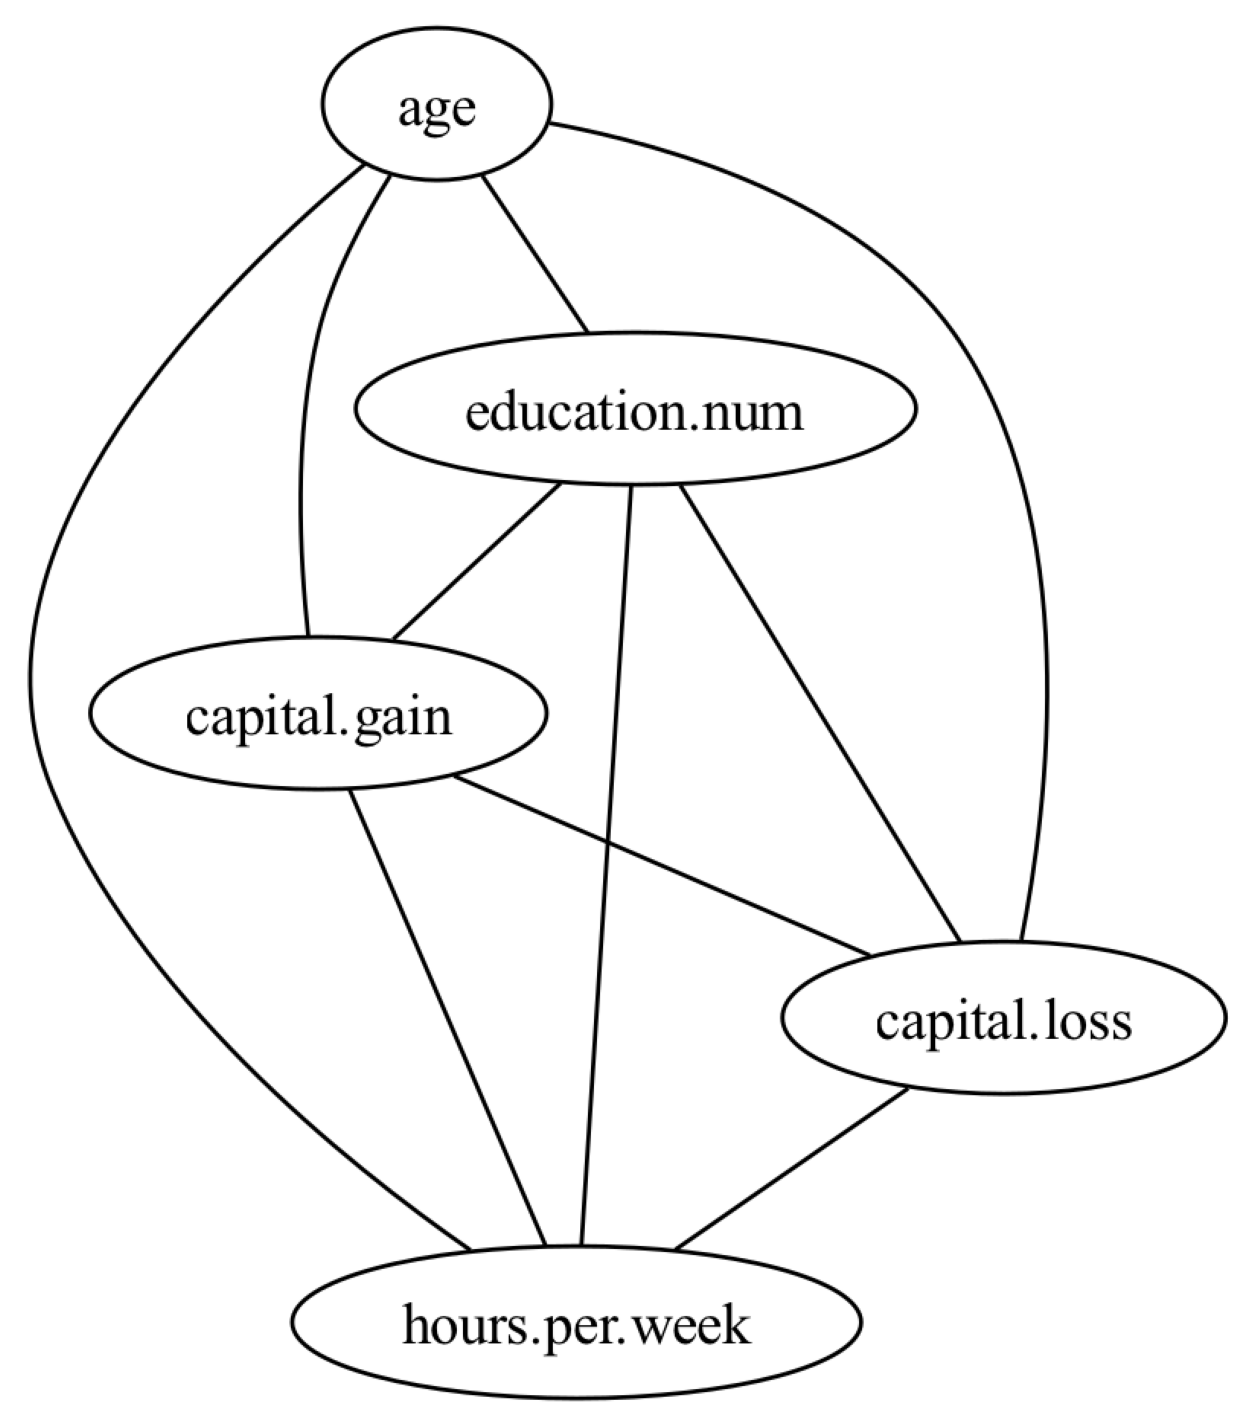

In [9]:
# Visualise the CPDAG
# Directed edges (→) = identified causal direction
# Undirected edges (—) = Markov-equivalent, direction cannot be determined
cg_cont.draw_pydot_graph(labels=node_names_cont)

## 4. PC Algorithm — All Variables (`chisq`)

When variables are discrete (or ordinal-encoded), use the **chi-squared CI test**.  
It tests independence via a contingency table, no Gaussianity assumption required.

> **Note:** Running PC on many variables is O(n^k) in the number of CI tests.  
> With 8 variables and a large n, this is still fast. With 15+ variables, consider
> sub-sampling or reducing to the most relevant columns first.

In [10]:
cg_disc = pc(
    data_disc,
    alpha=0.05,
    indep_test=chisq,     # chi-squared test — for discrete / categorical data
    stable=True,
    uc_rule=0,
    uc_priority=2,
    node_names=node_names_disc,
    show_progress=True,
)

  0%|          | 0/8 [00:00<?, ?it/s]

In [11]:
print("Edge list (CPDAG — discrete):")
for edge in cg_disc.G.get_graph_edges():
    print(f"  {edge}")

Edge list (CPDAG — discrete):
  age --> education.num
  age --> hours.per.week
  age --- marital.status
  age --> occupation
  age --- relationship
  age --> sex
  age --> income
  hours.per.week --> education.num
  marital.status --> education.num
  education.num --- occupation
  relationship --> education.num
  education.num --- sex
  education.num --> income
  marital.status --> hours.per.week
  hours.per.week --> occupation
  sex --> hours.per.week
  hours.per.week --- income
  marital.status --> occupation
  marital.status --- relationship
  marital.status --> sex
  marital.status --> income
  relationship --> occupation
  occupation --- sex
  occupation --> income
  relationship --> sex
  income --> sex


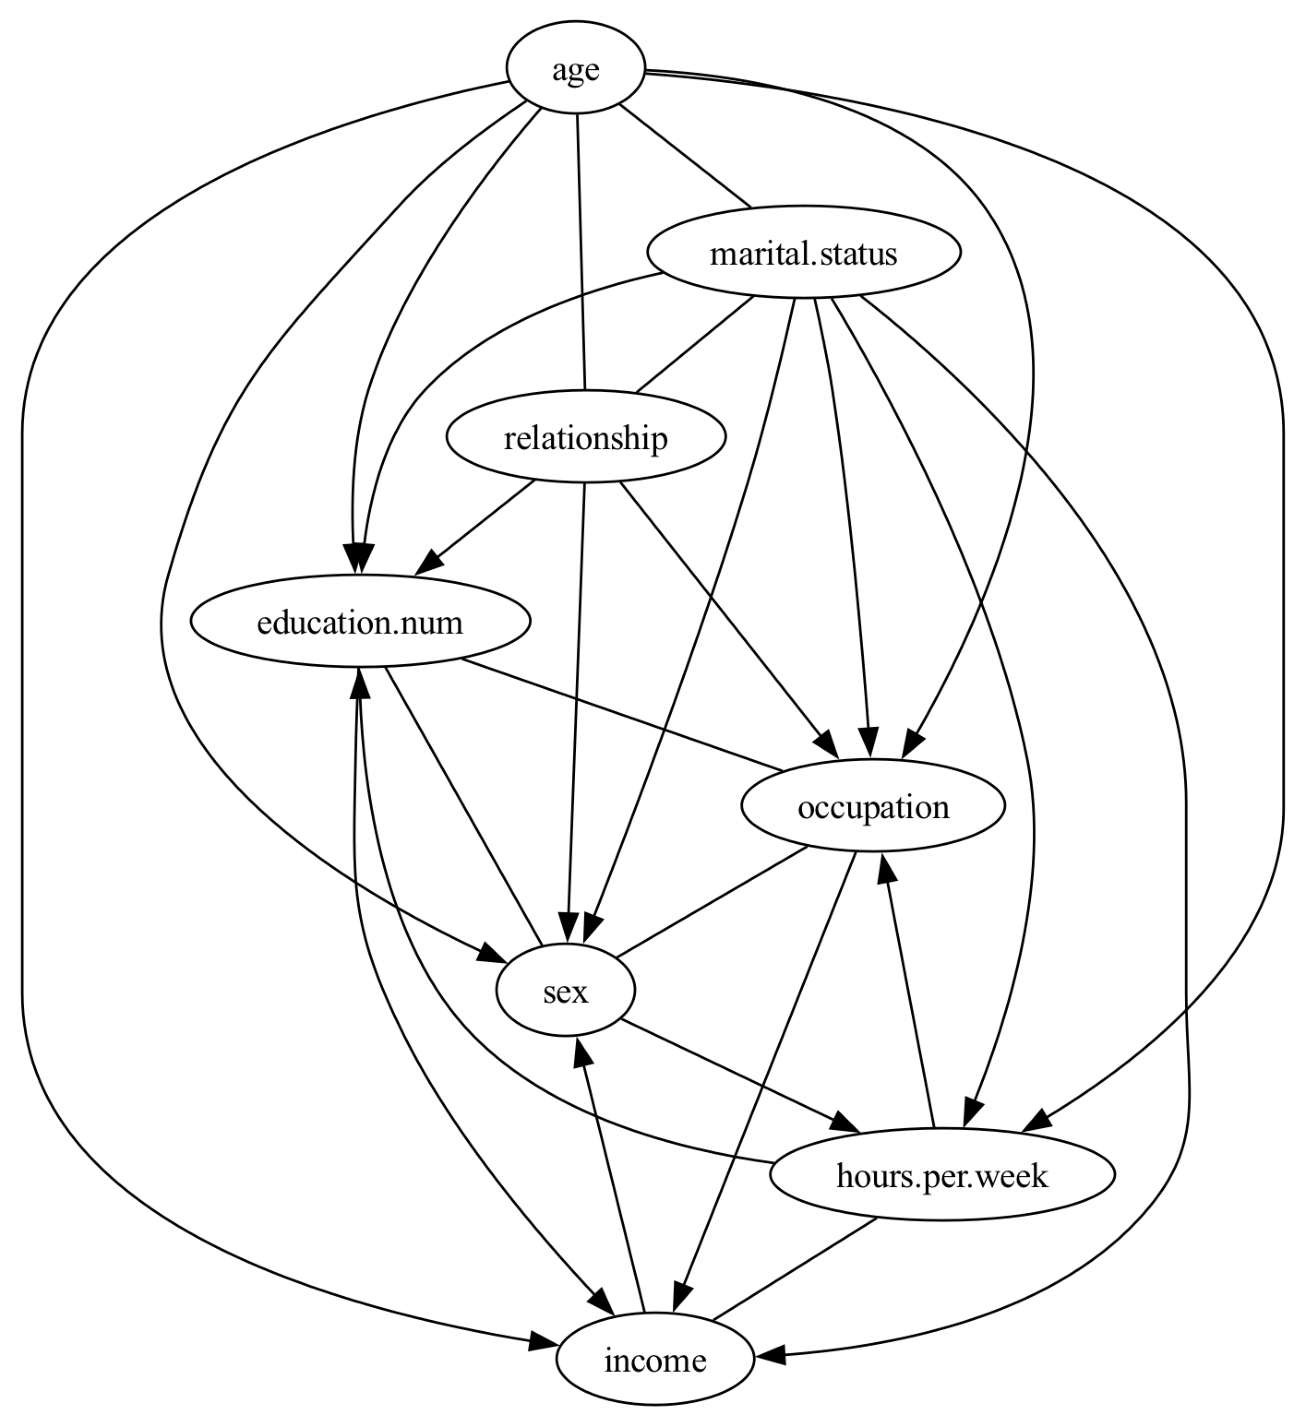

In [12]:
cg_disc.draw_pydot_graph(labels=node_names_disc)

## 4b. PC with Background Knowledge — Fixing Immutable Variables

### Why the unconstrained PC graph is wrong here

PC is a purely statistical algorithm. It orients edges by detecting **v-structures** (`X → Z ← Y`) and propagating orientations via **Meek rules**. It has no concept of time, logic, or immutability.

Within a Markov equivalence class, `X → Y` and `Y → X` fit the data equally well — PC picks one arbitrarily when the CI tests cannot distinguish them. This produced clearly wrong orientations in section 4:

| Nonsensical edge | Why it's impossible |
|-----------------|-------------------|
| `income --> sex` | Sex is determined at birth; earnings cannot cause it |
| `age --> sex` | Same — sex cannot be caused by any variable in this dataset |
| `marital.status --> sex` | Same |
| `relationship --> sex` | Same |
| `hours.per.week --> education.num` | Education is completed before most work history is set |
| `marital.status --> education.num` | Education typically precedes marriage |

### The fix: background knowledge constraints

`BackgroundKnowledge` lets you inject hard constraints **before** the orientation phase:

- `add_forbidden_by_node(src, dst)` — forbids the edge `src → dst`  
- `add_required_by_node(src, dst)` — forces the edge `src → dst`

We forbid **all arrows pointing into immutable variables** (`sex`, `age`). No variable in this dataset can cause them — they are fixed prior to any economic outcome being measured.

In [13]:
# Variables that cannot have parents — fixed before any economic outcome
IMMUTABLE = ["sex", "age"]

bk = BackgroundKnowledge()

# Build a node lookup from the graph produced in section 4
node_map = {node.get_name(): node for node in cg_disc.G.get_nodes()}

for immutable in IMMUTABLE:
    for other in node_names_disc:
        if other != immutable:
            # Forbid: other → immutable
            bk.add_forbidden_by_node(node_map[other], node_map[immutable])

cg_bk = pc(
    data_disc,
    alpha=0.05,
    indep_test=chisq,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    node_names=node_names_disc,
    show_progress=True,
)

  0%|          | 0/8 [00:00<?, ?it/s]

In [14]:
print("Edge list (CPDAG — with background knowledge):")
for edge in cg_bk.G.get_graph_edges():
    print(f"  {edge}")

Edge list (CPDAG — with background knowledge):
  age --> education.num
  age --> hours.per.week
  age --> marital.status
  age --> occupation
  age --> relationship
  age --> income
  hours.per.week --> education.num
  marital.status --> education.num
  education.num --- occupation
  relationship --> education.num
  sex --> education.num
  education.num --> income
  hours.per.week --- marital.status
  hours.per.week --> occupation
  sex --> hours.per.week
  hours.per.week --> income
  marital.status --> occupation
  marital.status --- relationship
  sex --> marital.status
  marital.status --> income
  relationship --> occupation
  sex --> occupation
  occupation --> income
  sex --> relationship
  sex --> income


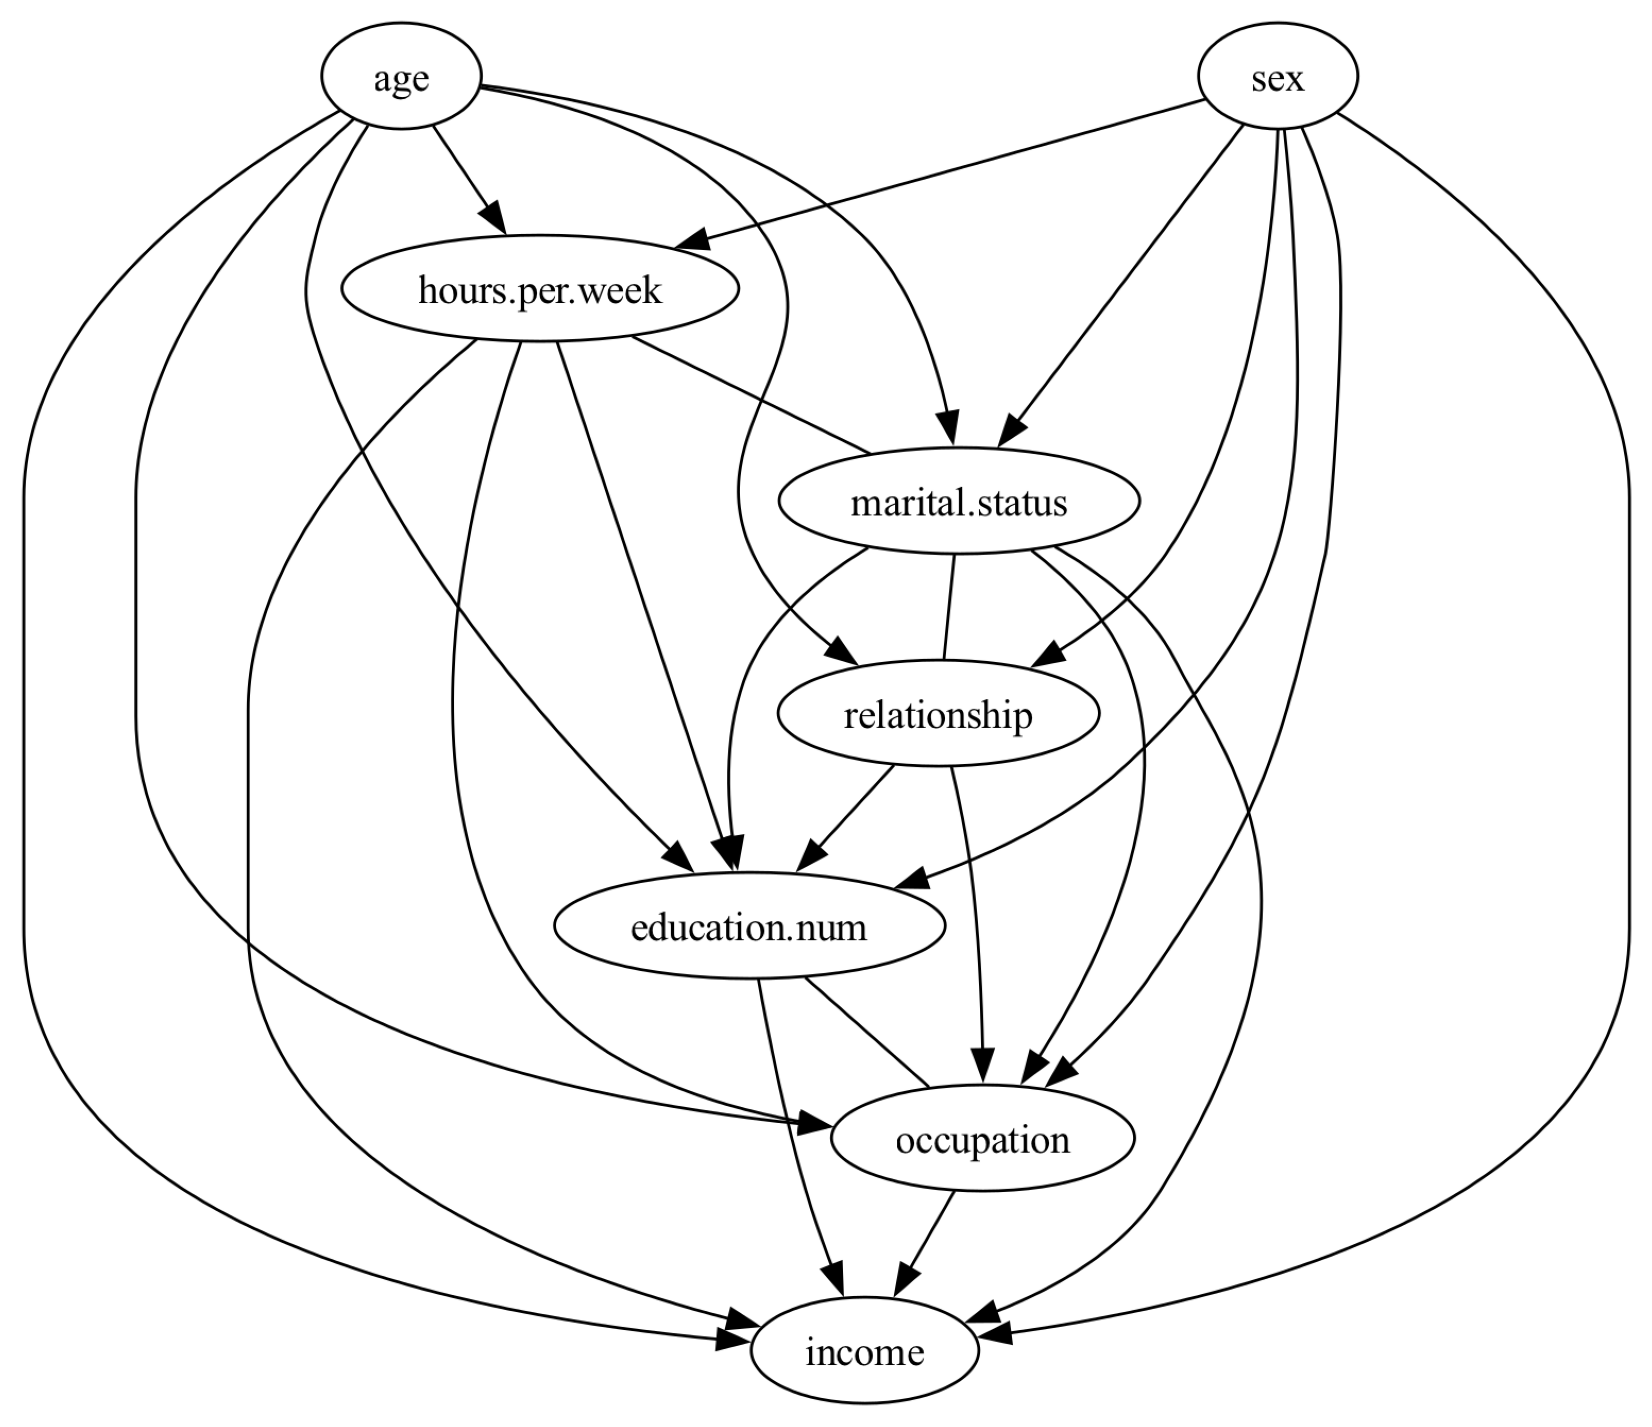

In [15]:
cg_bk.draw_pydot_graph(labels=node_names_disc)

## 5. FCI Algorithm — Allowing for Hidden Confounders

**Why FCI?**  
PC assumes **causal sufficiency** — no unobserved common causes. In real data this is rarely true.  
FCI (Fast Causal Inference) relaxes this assumption and can output **bi-directed edges** (`↔`) indicating a latent common cause.

The output is a **PAG** (Partial Ancestral Graph). Edge marks:

| Mark | Symbol | Meaning |
|------|--------|---------|
| Arrowhead `>` | `→` | definite causal direction |
| Tail `-` | `—` | definitely not into the node |
| Circle `o` | `o→` or `o—o` | uncertainty: could be tail or arrowhead |
| Bi-directed `↔` | `<->` | latent common cause exists |

> FCI is slower than PC because it runs additional independence tests to resolve circle marks.

In [16]:
# Run FCI with the same background knowledge as section 4b:
# sex and age cannot have parents in this dataset.
G_fci, edges_fci = fci(
    data_disc,
    independence_test_method=chisq,
    alpha=0.05,
    background_knowledge=bk,
    node_names=node_names_disc,
    show_progress=True,
)

print("FCI edges (PAG):")
for edge in edges_fci:
    print(f"  {edge}")

  0%|          | 0/8 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): age --> education.num
Orienting edge (Knowledge): age --> hours.per.week
Orienting edge (Knowledge): age --> marital.status
Orienting edge (Knowledge): age --> occupation
Orienting edge (Knowledge): age --> relationship
Orienting edge (Knowledge): age --> income
Orienting edge (Knowledge): sex --> education.num
Orienting edge (Knowledge): sex --> hours.per.week
Orienting edge (Knowledge): sex --> marital.status
Orienting edge (Knowledge): sex --> occupation
Orienting edge (Knowledge): sex --> relationship
Orienting edge (Knowledge): sex --> income
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): age --> education.num
Orienting edge (Knowledge): age --> hours.per.week
Orienting edge (Knowledge): age --> marital.status
Orienting edge (Knowledge): age --> occupation
Orienting edge (Knowledge): age --> relationship
Orienting edge (Knowledge): age --> income
Orienting edge (Knowledge): sex --> education.num
O

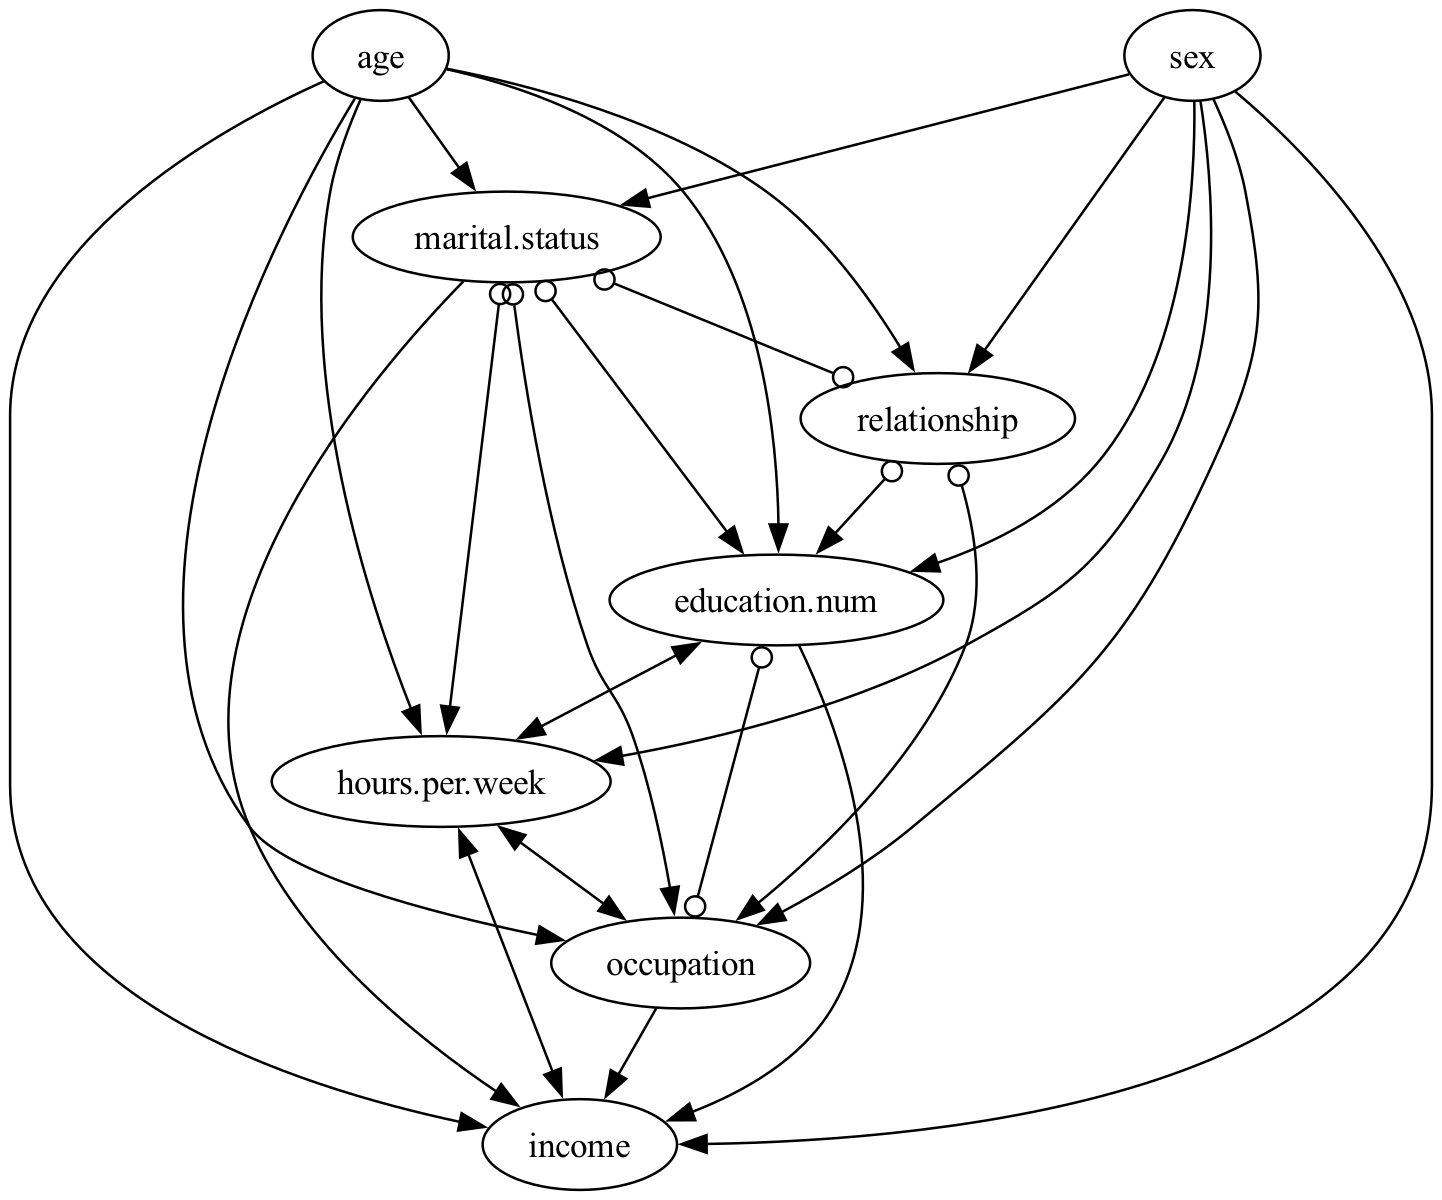

In [17]:
# Visualise the PAG
# o→ edges = direction uncertain but arrowhead is definite on one end
# ↔  edges = latent common cause
pyd = GraphUtils.to_pydot(G_fci, labels=node_names_disc)
pyd.set_size('"8,6!"')

from IPython.display import Image
Image(pyd.create_png())

## 6. LLM Graph Review

The FCI output still contains uncertain edges (`o->`, `o-o`) and a few that may be directionally wrong. Rather than adding more hard-coded background knowledge constraints, we use an LLM to review every edge with domain knowledge and return structured decisions.

**Pipeline:**
1. `decode_adj_matrix` converts the adjacency matrix → typed `EdgeInput` objects
2. `CausalGraphReviewer.review()` sends all edges in one call, forces structured output via tool use
3. The LLM returns one `EdgeDecision` per edge: `keep / remove / reverse / orient`
4. `apply_corrections()` writes those decisions back into a corrected adjacency matrix

**Switching providers** is one line — swap the adapter class:
```python
adapter = AnthropicAdapter("claude-opus-4-5")   # Anthropic
adapter = OpenAIAdapter("gpt-4o")               # OpenAI
adapter = GeminiAdapter("gemini-1.5-pro")       # Gemini
```

API keys are read from `secrets/secrets.yaml` (gitignored).

In [18]:
from src.causal_llm_review import (
    AnthropicAdapter,
    OpenAIAdapter,
    GeminiAdapter,
    CausalGraphReviewer,
    decode_adj_matrix,
)

# ── Pick a provider (swap this one line to change) ────────────────────────────
adapter  = OpenAIAdapter("gpt-4.1")   # reads secrets/secrets.yaml
reviewer = CausalGraphReviewer(adapter)

In [19]:
# ── Dataset context (edit this to match your data) ───────────────────────────
# Free text describing variable meanings. The LLM uses this as domain knowledge.
# Set to None to let the LLM rely purely on its built-in knowledge.

DATASET_CONTEXT = """
Adult Census Income dataset — extracted from the 1994 US Census Bureau database
by Barry Becker. The prediction task is whether a person earns >$50K/year.

Variables used in this causal graph (8 of the original 14):

- age: integer, continuous. Person's age in years (range 17–90).
- education.num: integer 1–16. Numeric encoding of education level
  (1 = Preschool, 9 = HS-grad, 10 = Some-college, 13 = Bachelors,
  14 = Masters, 16 = Doctorate). This is the numeric form of the
  categorical "education" column.
- hours.per.week: integer, continuous. Usual hours worked per week (1–99).
- marital.status: categorical (7 levels): Married-civ-spouse, Divorced,
  Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: categorical (14 levels): Tech-support, Craft-repair,
  Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners,
  Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving,
  Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: categorical (6 levels): Wife, Own-child, Husband,
  Not-in-family, Other-relative, Unmarried. Represents the person's role
  within the household. Note: this is closely related to marital.status.
- sex: binary — Female / Male.
- income: binary target — <=50K or >50K annual income.

Missing values (encoded as '?') appear in workclass, occupation, and
native.country. Rows with missing occupation were dropped before analysis.
"""

# ── Optional extra rules ──────────────────────────────────────────────────────
# Add domain constraints here, or leave as None to let the LLM reason freely.
# Example: "age and sex are determined at birth and cannot be caused by any
#           other variable in this dataset."

DOMAIN_RULES = None

In [20]:
# Decode the FCI adjacency matrix into a typed edge list
edges_for_review = decode_adj_matrix(G_fci.graph, node_names_disc)

print(f"Edges to review: {len(edges_for_review)}\n")
for i, e in enumerate(edges_for_review, 1):
    print(f"  {i:2d}. {e.node_from} {e.mark} {e.node_to}")

Edges to review: 20

   1. age --> education.num
   2. age --> hours.per.week
   3. age --> marital.status
   4. age --> occupation
   5. age --> relationship
   6. age --> income
   7. education.num <-> hours.per.week
   8. education.num o-o occupation
   9. sex --> education.num
  10. education.num --> income
  11. hours.per.week <-> occupation
  12. sex --> hours.per.week
  13. hours.per.week <-> income
  14. marital.status o-o relationship
  15. sex --> marital.status
  16. marital.status --> income
  17. sex --> occupation
  18. occupation --> income
  19. sex --> relationship
  20. sex --> income


In [21]:
# Send to the LLM — one API call, structured output via tool use
decisions = reviewer.review(
    edges=edges_for_review,
    node_names=node_names_disc,
    dataset_context=DATASET_CONTEXT,
    domain_rules=DOMAIN_RULES,
)

print(f"Received {len(decisions)} decisions")

Received 20 decisions


In [22]:
# Display the full review as a table
df_decisions = pd.DataFrame([
    {
        "Original edge":  f"{d.node_from} {d.original_mark} {d.node_to}",
        "Action":         d.action,
        "Corrected edge": f"{d.node_from} {d.corrected_mark} {d.node_to}"
                          if d.corrected_mark != "none" else "(removed)",
        "Confidence":     d.confidence,
        "Reasoning":      d.reasoning,
    }
    for d in decisions
])

pd.set_option("display.max_colwidth", 200)
df_decisions

,Original edge,Action,Corrected edge,Confidence,Reasoning
0,age --> education.num,keep,age --> education.num,high,"Age temporally precedes accumulated education and strongly influences completed education years, especially for adults where increased age generally allows for more completed education."
1,age --> hours.per.week,keep,age --> hours.per.week,medium,"Age plausibly affects hours worked due to workforce entry, peak earning years, and retirement, though the relationship can be complicated (e.g. by health, career, or life stage)."
2,age --> marital.status,keep,age --> marital.status,high,"Marital status is a state that typically depends on age. One must reach a minimum age to marry, and likelihood of various statuses (married, widowed) increases with age."
3,age --> occupation,keep,age --> occupation,medium,"Older individuals may advance to certain occupations or move between occupations over their life course; while background factors are important, temporal logic supports age as a direct/indirect ca..."
4,age --> relationship,keep,age --> relationship,medium,"Age affects relationship roles (e.g., minor vs. spouse vs. parent) within a household—children, for example, are characteristically younger."
5,age --> income,keep,age --> income,medium,There is a plausible causal pathway from age to income: younger and older (retired) people tend to earn less; main lifetime earnings occur at middle ages.
6,education.num <-> hours.per.week,keep,education.num <-> hours.per.week,medium,"There may be latent confounders (e.g., socioeconomic status, career ambition, health) affecting both education level and hours worked, so latent common cause is plausible."
7,education.num o-o occupation,orient,education.num --> occupation,medium,"Education level plausibly precedes and partly determines occupation by influencing eligibility, though reverse causation is unlikely for adults."
8,sex --> education.num,keep,sex --> education.num,medium,"Sex can influence opportunities or cultural/familial influences on education historically, not vice versa (as education cannot determine one's sex)."
9,education.num --> income,keep,education.num --> income,high,"Educational attainment consistently increases access to higher-paying jobs; this is a classic, direct effect supported across contexts."


In [23]:
# Apply decisions to produce a corrected adjacency matrix
adj_fci_orig      = G_fci.graph.copy()
adj_fci_corrected = reviewer.apply_corrections(adj_fci_orig, decisions, node_names_disc)

# Show what changed
n = len(node_names_disc)
changed = [
    (node_names_disc[i], node_names_disc[j])
    for i in range(n) for j in range(i + 1, n)
    if adj_fci_orig[i, j] != adj_fci_corrected[i, j]
    or adj_fci_orig[j, i] != adj_fci_corrected[j, i]
]
print(f"Edges modified: {len(changed)}")
for a, b in changed:
    i, j = node_names_disc.index(a), node_names_disc.index(b)
    print(f"  {a} — {b}:  "
          f"({adj_fci_orig[i,j]:+d},{adj_fci_orig[j,i]:+d})  →  "
          f"({adj_fci_corrected[i,j]:+d},{adj_fci_corrected[j,i]:+d})")

Edges modified: 2
  education.num — occupation:  (+2,+2)  →  (-1,+1)
  marital.status — relationship:  (+2,+2)  →  (-1,+1)


── Original FCI PAG ─────────────────────────────────────────────────────


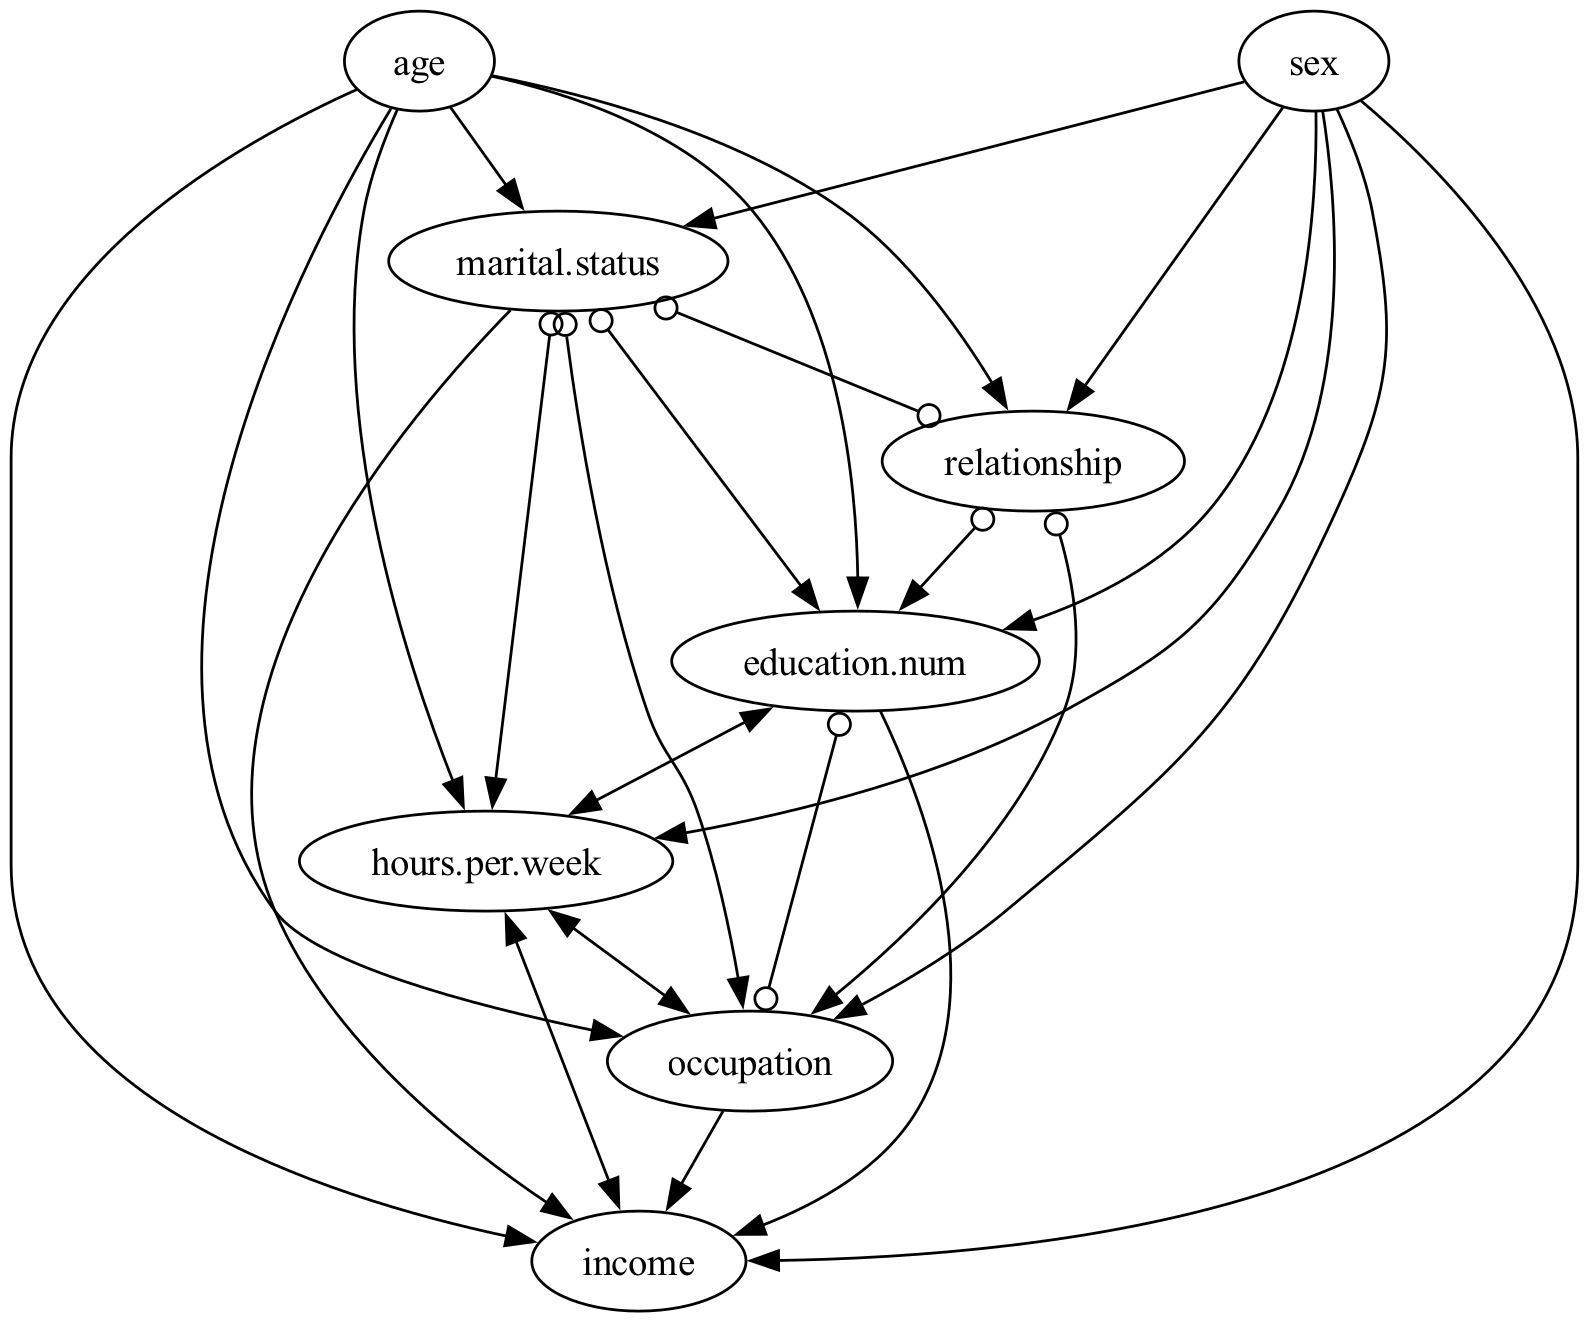

── LLM-corrected graph ──────────────────────────────────────────────────


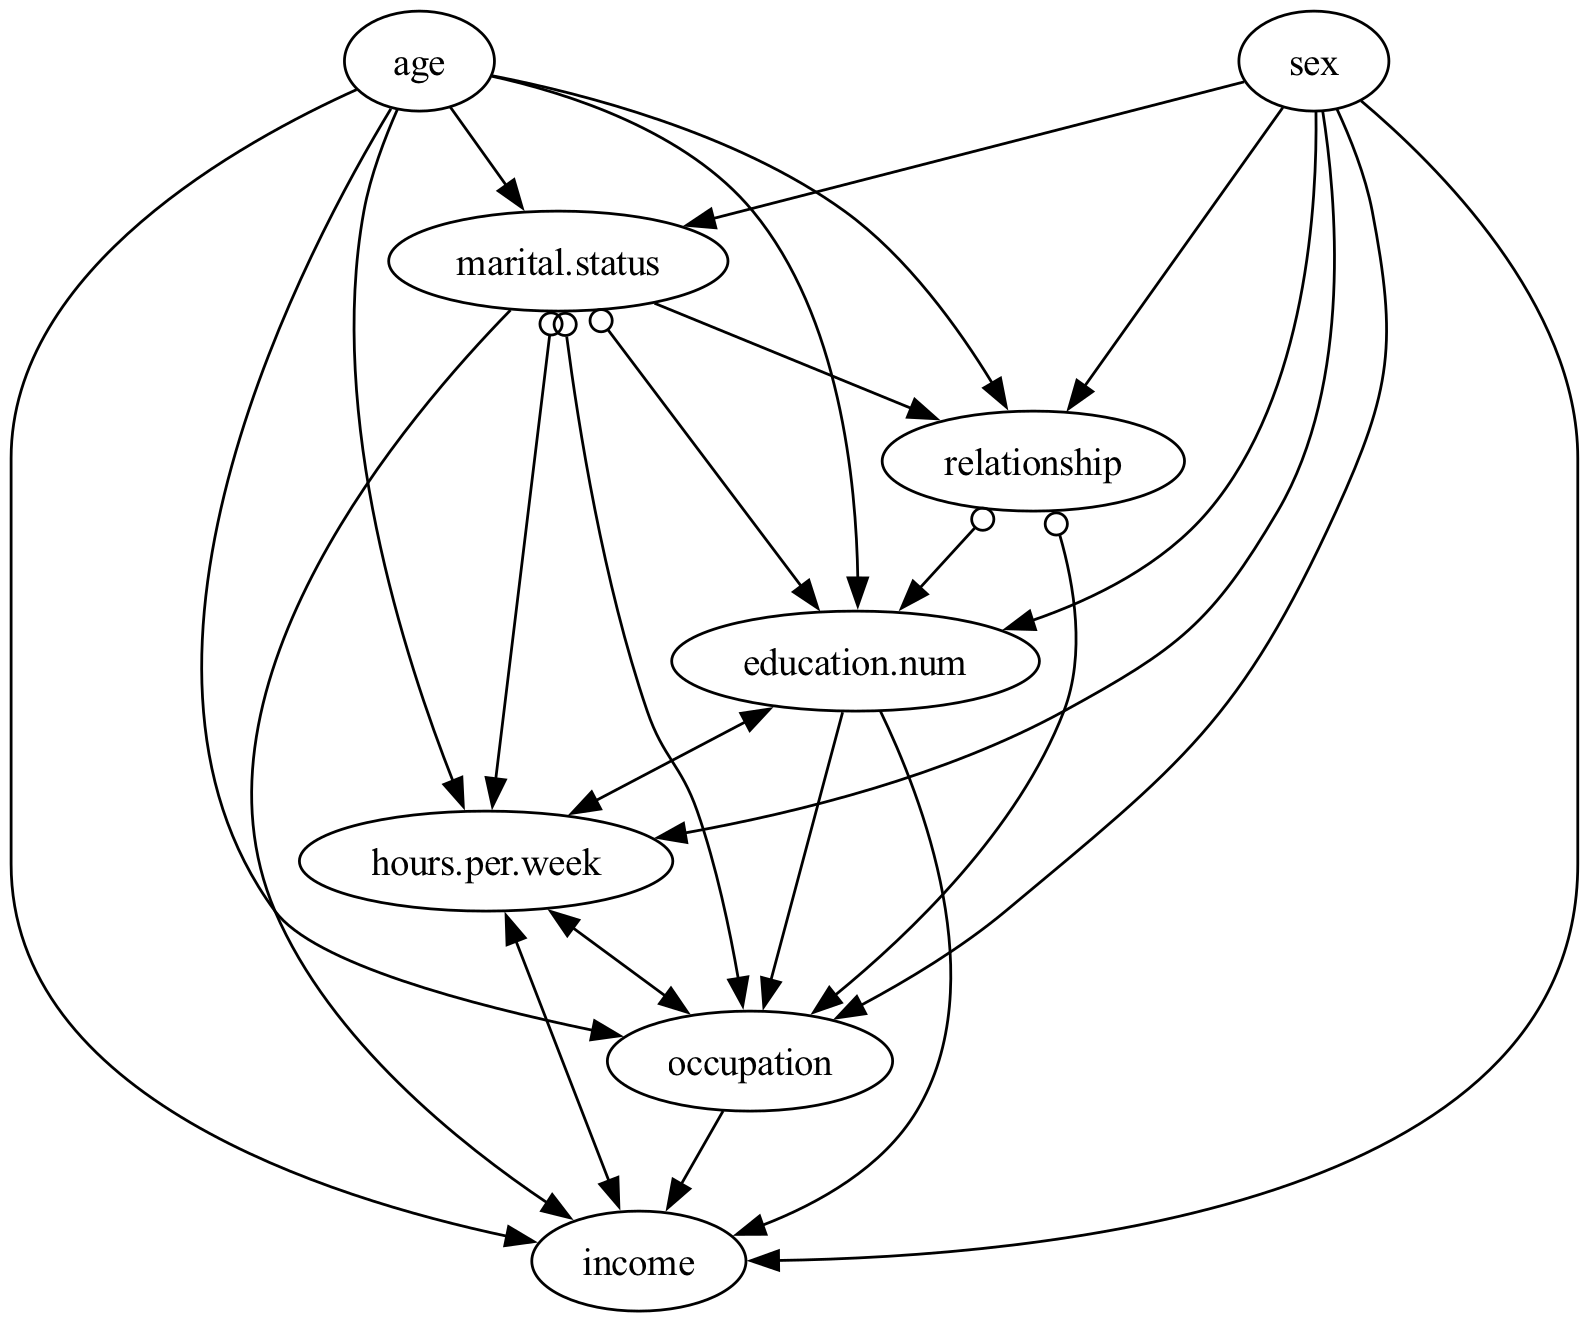

In [24]:
from IPython.display import Image, display
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.graph.GraphNode import GraphNode

# Reconstruct a GeneralGraph from the corrected matrix so we can reuse GraphUtils
nodes_obj   = [GraphNode(n) for n in node_names_disc]
G_corrected = GeneralGraph(nodes_obj)
G_corrected.graph = adj_fci_corrected

print("── Original FCI PAG ─────────────────────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_fci, labels=node_names_disc).create_png()))

print("── LLM-corrected graph ──────────────────────────────────────────────────")
display(Image(GraphUtils.to_pydot(G_corrected, labels=node_names_disc).create_png()))